In [1]:
import os
os.chdir('../')

# Analysis for 1PV for the flamelet dataset: effect of the QoI scaling at the decoder's output

In [2]:
from EncoderDecoder.utils import loadData
import matplotlib.pyplot as plt
import logging
from matplotlib.lines import Line2D
import numpy as np
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import re
logging.disable(logging.CRITICAL)

In [3]:
path_data = "data-files/"

C:\Windows\Temp\ipykernel_28552\1336229652.py:46: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


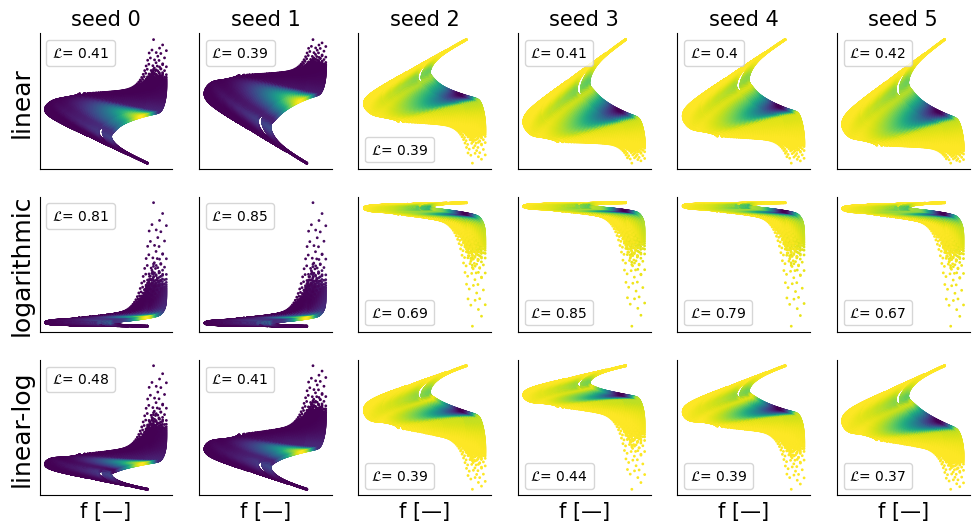

In [16]:
save = True
savePath = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-NOx/Experiments/Scaling QoIs/"
saveName = "2026-06-10 - 1PV flamelet - linLog QoIs"

scalingQoIs = ["lin", "log", "linLog"]
scalingLabels = ["linear", "logarithmic", "linear-log"]
nbr_seeds = 6

fig, axes = plt.subplots(len(scalingQoIs), nbr_seeds, figsize=(12, 6))

for idxScaling, scaling in enumerate(scalingQoIs):
    for seed in range(nbr_seeds):
        filename = f"Tr1_1PV_RMSprop_250_{scaling}_s{seed}-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"

        loader = loadData(filename)
        extraVars, PV, PVsource = loader.getManifoldParameters(path_data, "flamelet")

        ax = axes[idxScaling, seed]
        ax.scatter(extraVars, PV, s=1, c = PVsource)
        ax.set_xticks([])
        ax.set_yticks([])

        dummy = Line2D([], [], linestyle='none')
        ax.legend(
            [dummy],
            [r'$\mathcal{L}$' + f"= {np.round(loader.getAvgCosts('flamelet'),2)}"],
            handlelength=0,
            handletextpad=0,
            frameon = True
        )

        if(seed == 0):
            ax.set_ylabel(scalingLabels[idxScaling], fontsize = 18)

        if(idxScaling == len(scalingQoIs)-1):
            ax.set_xlabel("f [\u2014]", fontsize = 15)
        elif(idxScaling == 0):
            ax.set_title(f"seed {seed}", fontsize = 15)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

if save:
    plt.savefig(savePath + saveName, dpi = 1000, bbox_inches = "tight")

fig.show()

C:\Windows\Temp\ipykernel_25060\1685043741.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_25060\1685043741.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  greys = cm.get_cmap('Greys')
C:\Windows\Temp\ipykernel_25060\1685043741.py:108: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


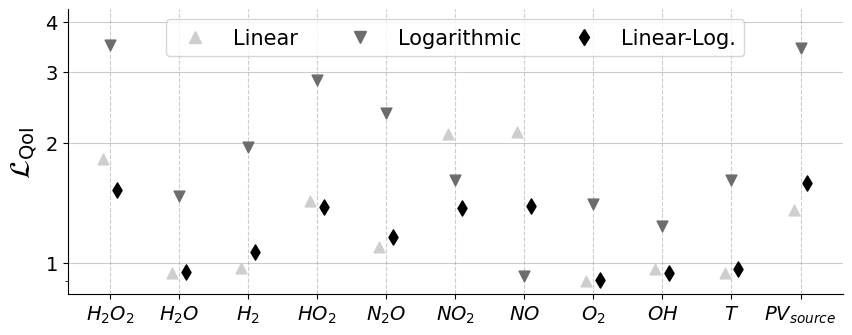

In [18]:
save = True
savePath = "C:/Users/Admin/Documents/PhD-ULB/Figures/2026-PV-optimization-for-NOx/Experiments/Scaling QoIs/"
saveName = "2026-06-11 - 1PV flamelet - linLog QoIs - QoI costs"

seed = 5
dataset_type = "flamelet"

filenameLin = f"Tr1_1PV_RMSprop_250_lin_s{seed}-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"
filenameLog = f"Tr1_1PV_RMSprop_250_log_s{seed}-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"
filenameLinLog = f"Tr1_1PV_RMSprop_250_linLog_s{seed}-AE-date_03Jun2026-hour_18h03_Xu-flamelet-augm"

loaderLin = loadData(filenameLin)
loaderLog = loadData(filenameLog)
loaderLinLog = loadData(filenameLinLog)

costsLin = loaderLin.getQoICosts(dataset_type)
costsLog = loaderLog.getQoICosts(dataset_type)
costsLinLog = loaderLinLog.getQoICosts(dataset_type)

fig, ax = plt.subplots(figsize=(10, 3.7))
#fig.tight_layout(pad=-30)

greys = cm.get_cmap('Greys')

QoIs = loaderLin.getListQoIs()

def smart_format_y_ticks(x, pos):
    if abs(x) < 1e-8:
        return "0"
    elif abs(x - round(x)) < 1e-8:
        return str(int(x))
    else:
        return f"{x:.1f}"

def format_species_name_for_latex(name: str) -> str:
    def repl(match):
        num = match.group(1)
        if num == "1":
            return "_{source}"
        return f"_{{{num}}}"

    return re.sub(r'(\d+)', repl, name)

greys = cm.get_cmap('Greys')

# x positions for species
x_positions = np.arange(len(QoIs))
width = 0.1  # horizontal offset between points

# plot each group of parameterizations around each species x
for i, qoi in enumerate(QoIs):
    x0 = x_positions[i]
    # small offsets around x0 for each point
    offsets = np.array([-1, 0, 1]) * width
    y_values = [
        costsLin[i],
        costsLog[i],
        costsLinLog[i]
    ]
    markers = ['^', 'v', 'd']   # triangles for heuristics, circles for optimized
    colors  = [greys(0.3), greys(0.65), greys(1.0)]   # all black, can customize if needed
    
    labels  = [
        "Linear",
        "Logarithmic",
        "Linear-Log."
    ]
    
    # Plot each point separately to apply marker type
    for dx, y, m, c in zip(offsets, y_values, markers, colors):
        ax.scatter(x0 + dx, y, marker=m, color=c, s=60, zorder=3)

handles = [plt.Line2D([0], [0], marker=m, color=c, linestyle='', markersize=8) 
           for m, c in zip(markers, colors)]

# Add legend **once**
ax.legend(handles, labels, ncols = 3, fontsize=15, loc='upper center')

# Label species on x-axis
species_labels = [format_species_name_for_latex(qoi) for qoi in QoIs]
ax.set_xticks(x_positions)
ax.set_xticklabels([f"${lbl}$" for lbl in species_labels], fontsize=14, rotation=0)


ax.set_yscale("log")
ax.set_yticks(np.arange(1,5))

# y-axis formatting
ax.yaxis.set_major_formatter(ticker.FuncFormatter(smart_format_y_ticks))
ax.tick_params(axis='y', labelsize=14)
ax.set_ylabel(r"$\mathcal{L}_{\mathrm{QoI}}$", fontsize=20)

for x in x_positions:
    ax.axvline(x=x, color='gray', linestyle='--', linewidth=0.8, alpha=0.4, zorder=0)

y_positions = range(5)

for y in y_positions:
    ax.axhline(y=y, color='gray', linestyle='-', linewidth=0.8, alpha=0.4, zorder=0)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

if save:
    plt.savefig(savePath + saveName, dpi = 1000, bbox_inches = "tight")
    plt.savefig(savePath + saveName + ".pdf", bbox_inches = "tight")

fig.show()